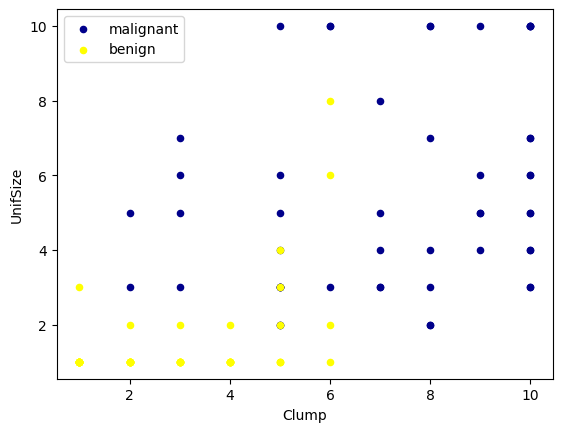

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)
              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

Confusion matrix, without normalization
[[85  5]
 [ 0 47]]

=== LINEAR ===
              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

Confusion matrix:
 [[85  5]
 [ 0 47]]

=== POLY ===
              precision    recall  f1-score   support

           2       1.00      0.96      0.98        90
           4       0.92      1.00      0.96        47

  

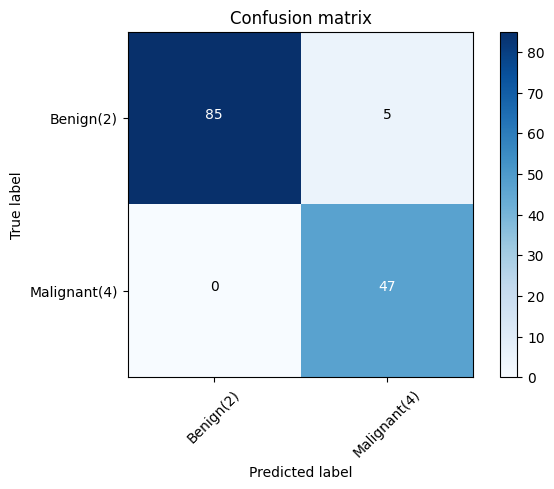

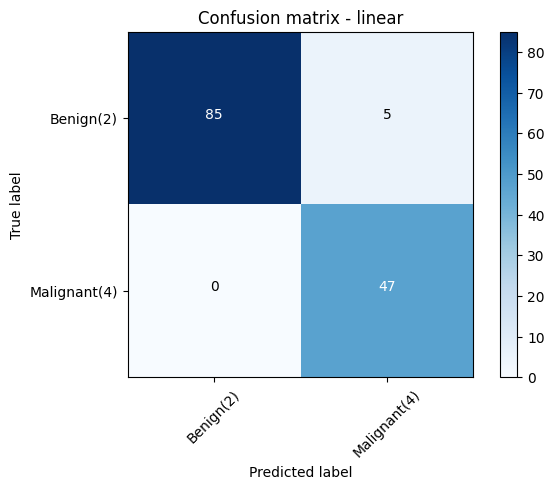

Confusion matrix, without normalization
[[86  4]
 [ 0 47]]


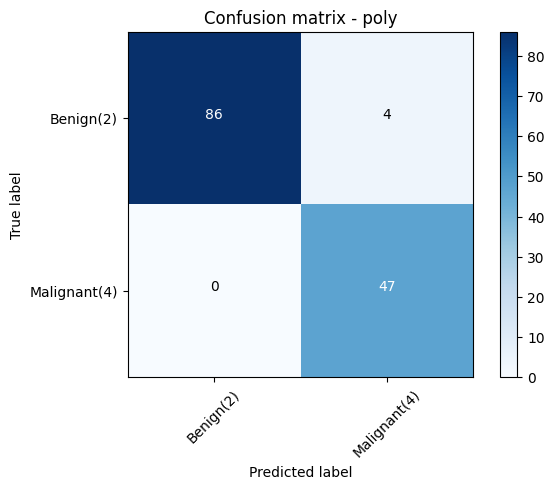

Confusion matrix, without normalization
[[54 36]
 [47  0]]


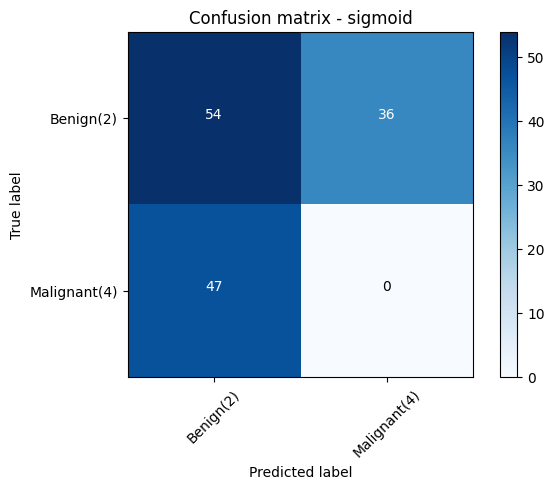

Confusion matrix, without normalization
[[85  5]
 [ 0 47]]


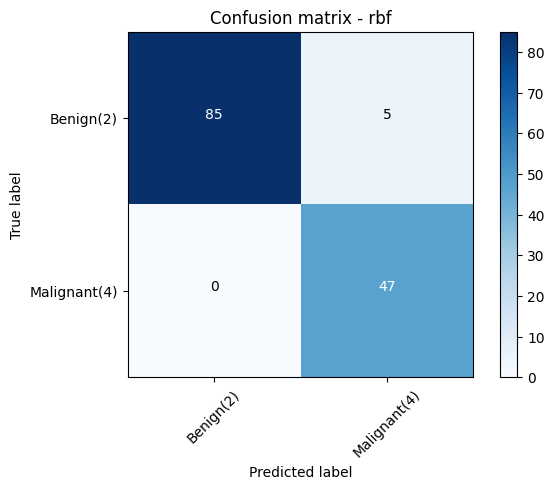

In [7]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline 
import matplotlib.pyplot as plt

cell_df = pd.read_csv("/home/jupyter/work/data/cell_samples.csv")
cell_df.head()

ax = cell_df[cell_df['Class'] == 4][0:50].plot(kind='scatter', x='Clump', y='UnifSize', 
                                               color='DarkBlue', label='malignant');
cell_df[cell_df['Class'] == 2][0:50].plot(kind='scatter', x='Clump', y='UnifSize', 
                                          color='Yellow', label='benign', ax=ax);
plt.show()

cell_df.dtypes

cell_df = cell_df[pd.to_numeric(cell_df['BareNuc'], errors='coerce').notnull()]
cell_df['BareNuc'] = cell_df['BareNuc'].astype('int')
cell_df.dtypes

feature_df = cell_df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 
                  'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]
X = np.asarray(feature_df)
X[0:5]

cell_df['Class'] = cell_df['Class'].astype('int')
y = np.asarray(cell_df['Class'])
y [0:5]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train)

yhat = clf.predict(X_test)
yhat [0:5]

from sklearn.metrics import classification_report, confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    
cnf_matrix = confusion_matrix(y_test, yhat, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))

plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],
                      normalize= False,  title='Confusion matrix')

from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted')

from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat, pos_label = 2)


from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, f1_score, jaccard_score, accuracy_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt

kernels = {
    "linear": svm.SVC(kernel='linear'),
    "poly": svm.SVC(kernel='poly', degree=3),   
    "sigmoid": svm.SVC(kernel='sigmoid'),
    "rbf": svm.SVC(kernel='rbf')                
}

results = []
conf_matrices = {}

for name, model in kernels.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    jacc = jaccard_score(y_test, y_pred, pos_label=2)  # как у вас
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    results.append({
        "kernel": name,
        "accuracy": acc,
        "f1_weighted": f1,
        "jaccard_pos2": jacc,
        "precision_weighted": prec,
        "recall_weighted": rec
    })

    conf_matrices[name] = confusion_matrix(y_test, y_pred, labels=[2, 4])

    print(f"\n=== {name.upper()} ===")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:\n", conf_matrices[name])

results_df = pd.DataFrame(results).sort_values(by="f1_weighted", ascending=False)
print("\nСравнение моделей:")
print(results_df)

for name in kernels.keys():
    plt.figure()
    plot_confusion_matrix(conf_matrices[name], classes=['Benign(2)','Malignant(4)'],
                          normalize=False, title=f'Confusion matrix - {name}')
    plt.show()